In [2]:
# On installe les outils dont on a besoin
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "seaborn"])

print("✅ Installation terminée !")

✅ Installation terminée !


In [1]:
import pandas as pd

# Charge le fichier CSV
df = pd.read_csv("data/dataset.csv", sep=";")

# Affiche les 5 premières lignes
df.head()

,"Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target"
0,"1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,..."
1,"1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,..."
2,"1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6..."
3,"1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,..."
4,"2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,..."


In [2]:
import pandas as pd

# On enlève sep=";" et on laisse pandas détecter automatiquement
df = pd.read_csv("data/dataset.csv")

print("Nombre d'étudiants :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre d'étudiants : 4424
Nombre de colonnes : 35


In [3]:
# Combien de lignes et de colonnes ?
print("Nombre d'étudiants :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

# Est-ce qu'il manque des données ?
print("\nValeurs manquantes :")
print(df.isnull().sum())

Nombre d'étudiants : 4424
Nombre de colonnes : 35

Valeurs manquantes :
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                           

In [7]:
# Combien d'étudiants dans chaque catégorie ?
print(df["Target"].value_counts())
print()

# En pourcentage
print(df["Target"].value_counts(normalize=True).mul(100).round(1))

Graduate    2209
Dropout     1421
Enrolled     794
Name: Target, dtype: int64

Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: Target, dtype: float64


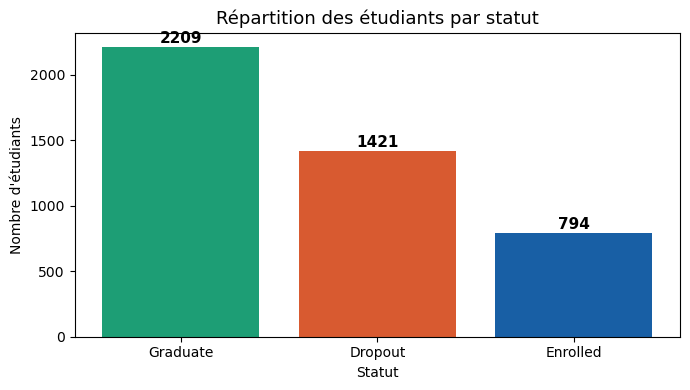

In [4]:
import matplotlib.pyplot as plt

# Compter les étudiants par statut
counts = df["Target"].value_counts()

# Créer le graphique
fig, ax = plt.subplots(figsize=(7, 4))

barres = ax.bar(
    counts.index,
    counts.values,
    color=["#1D9E75", "#D85A30", "#185FA5"]
)

# Ajouter les chiffres au-dessus des barres
for barre in barres:
    hauteur = barre.get_height()
    ax.text(
        barre.get_x() + barre.get_width() / 2,
        hauteur + 30,
        str(hauteur),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Répartition des étudiants par statut", fontsize=13)
ax.set_xlabel("Statut")
ax.set_ylabel("Nombre d'étudiants")

plt.tight_layout()
plt.savefig("figures/01_repartition.png")  # sauvegarde dans ton dossier
plt.show()

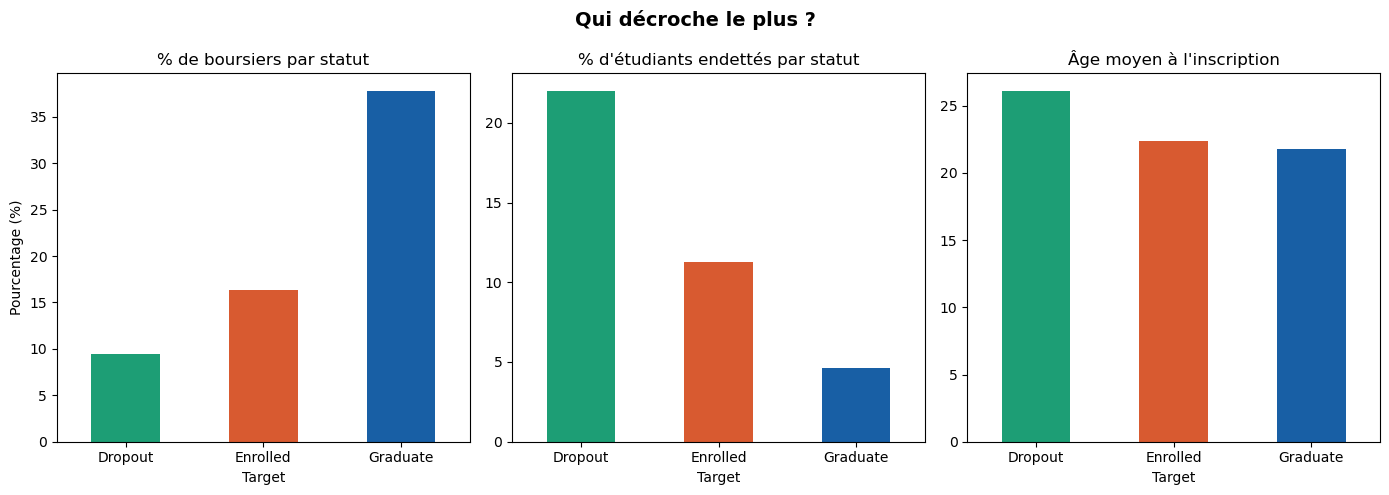

In [9]:
# Compare les décrocheurs vs diplômés sur 3 facteurs clés
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. Les boursiers décrochent-ils moins ?
df.groupby("Target")["Scholarship holder"].mean().mul(100).round(1).plot(
    kind="bar", ax=axes[0],
    color=["#1D9E75", "#D85A30", "#185FA5"],
    rot=0
)
axes[0].set_title("% de boursiers par statut")
axes[0].set_ylabel("Pourcentage (%)")

# 2. Les dettes influencent-elles le décrochage ?
df.groupby("Target")["Debtor"].mean().mul(100).round(1).plot(
    kind="bar", ax=axes[1],
    color=["#1D9E75", "#D85A30", "#185FA5"],
    rot=0
)
axes[1].set_title("% d'étudiants endettés par statut")

# 3. L'âge moyen à l'inscription
df.groupby("Target")["Age at enrollment"].mean().round(1).plot(
    kind="bar", ax=axes[2],
    color=["#1D9E75", "#D85A30", "#185FA5"],
    rot=0
)
axes[2].set_title("Âge moyen à l'inscription")

plt.suptitle("Qui décroche le plus ?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/02_facteurs.png")
plt.show()

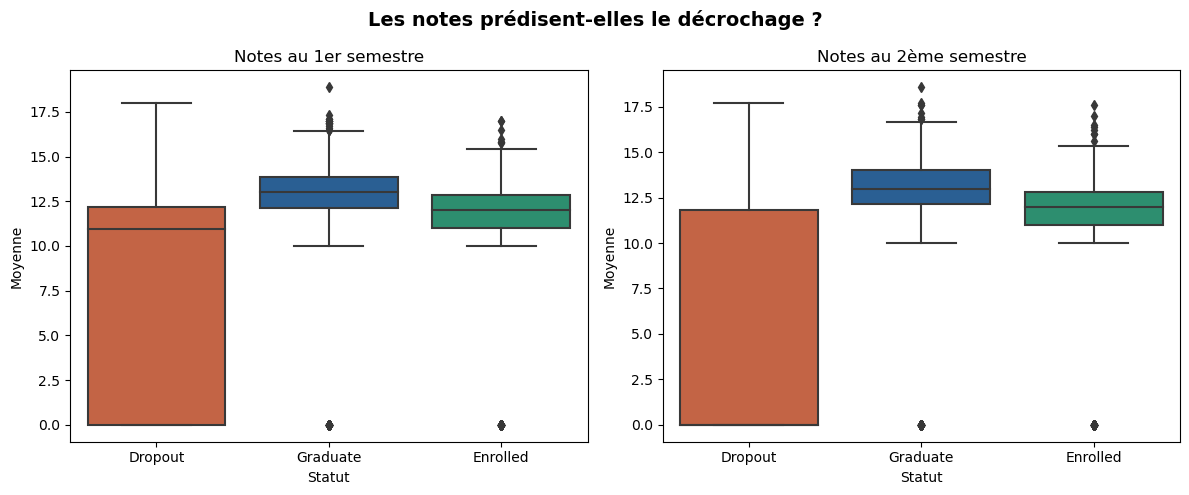

In [10]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Notes du 1er semestre
sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 1st sem (grade)",
    palette=["#D85A30", "#185FA5", "#1D9E75"],
    ax=axes[0]
)
axes[0].set_title("Notes au 1er semestre")
axes[0].set_xlabel("Statut")
axes[0].set_ylabel("Moyenne")

# Notes du 2ème semestre
sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 2nd sem (grade)",
    palette=["#D85A30", "#185FA5", "#1D9E75"],
    ax=axes[1]
)
axes[1].set_title("Notes au 2ème semestre")
axes[1].set_xlabel("Statut")
axes[1].set_ylabel("Moyenne")

plt.suptitle("Les notes prédisent-elles le décrochage ?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/03_notes.png")
plt.show()

In [5]:
# Phase 2

from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# On transforme la colonne Target en chiffres
# Dropout = 0, Graduate = 1, Enrolled = 2
le = LabelEncoder()
df_model["Target"] = le.fit_transform(df_model["Target"])

print("Correspondance des catégories :")
for i, classe in enumerate(le.classes_):
    print(f"  {classe} → {i}")

print("\nNombre d'étudiants par catégorie :")
print(df_model["Target"].value_counts())

Correspondance des catégories :
  Dropout → 0
  Enrolled → 1
  Graduate → 2

Nombre d'étudiants par catégorie :
2    2209
0    1421
1     794
Name: Target, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

# X = les informations sur les étudiants (les questions de l'examen)
# y = le statut final (les réponses)
X = df_model.drop("Target", axis=1)
y = df_model["Target"]

# On coupe : 80% pour apprendre, 20% pour tester
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Données d'apprentissage :", X_train.shape[0], "étudiants")
print("Données de test :", X_test.shape[0], "étudiants")

Données d'apprentissage : 3539 étudiants
Données de test : 885 étudiants


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Créer le modèle
modele = LogisticRegression(max_iter=1000, random_state=42)

# Le faire apprendre sur les données d'apprentissage
modele.fit(X_train, y_train)

# Le tester sur les données de test
y_pred = modele.predict(X_test)

# Voir les résultats
print("=== Résultats du modèle ===\n")
print(f"Précision globale : {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nDétail par catégorie :")
print(classification_report(y_test, y_pred,
      target_names=["Dropout", "Enrolled", "Graduate"]))

=== Résultats du modèle ===

Précision globale : 75.6%

Détail par catégorie :
              precision    recall  f1-score   support

     Dropout       0.81      0.78      0.80       316
    Enrolled       0.49      0.25      0.33       151
    Graduate       0.76      0.92      0.83       418

    accuracy                           0.76       885
   macro avg       0.69      0.65      0.65       885
weighted avg       0.73      0.76      0.73       885



C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.ensemble import RandomForestClassifier

# Créer le modèle Random Forest
rf = RandomForestClassifier(
    n_estimators=100,  # 100 arbres de décision
    random_state=42
)

# Apprendre et entraîner
rf.fit(X_train, y_train)

# Tester
y_pred_rf = rf.predict(X_test)

# Résultats
print("=== Résultats Random Forest ===\n")
print(f"Précision globale : {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print("\nDétail par catégorie :")
print(classification_report(y_test, y_pred_rf,
      target_names=["Dropout", "Enrolled", "Graduate"]))

=== Résultats Random Forest ===

Précision globale : 77.3%

Détail par catégorie :
              precision    recall  f1-score   support

     Dropout       0.84      0.76      0.80       316
    Enrolled       0.53      0.32      0.40       151
    Graduate       0.78      0.94      0.85       418

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.68       885
weighted avg       0.76      0.77      0.76       885



In [10]:
import subprocess
subprocess.run(["pip", "install", "xgboost"])
print("✅ XGBoost installé !")

✅ XGBoost installé !


In [11]:
from xgboost import XGBClassifier

# Créer le modèle XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="mlogloss",
    verbosity=0
)

# Apprendre et entraîner
xgb.fit(X_train, y_train)

# Tester
y_pred_xgb = xgb.predict(X_test)

# Résultats
print("=== Résultats XGBoost ===\n")
print(f"Précision globale : {accuracy_score(y_test, y_pred_xgb)*100:.1f}%")
print("\nDétail par catégorie :")
print(classification_report(y_test, y_pred_xgb,
      target_names=["Dropout", "Enrolled", "Graduate"]))

=== Résultats XGBoost ===

Précision globale : 75.9%

Détail par catégorie :
              precision    recall  f1-score   support

     Dropout       0.83      0.75      0.79       316
    Enrolled       0.48      0.40      0.44       151
    Graduate       0.79      0.90      0.84       418

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



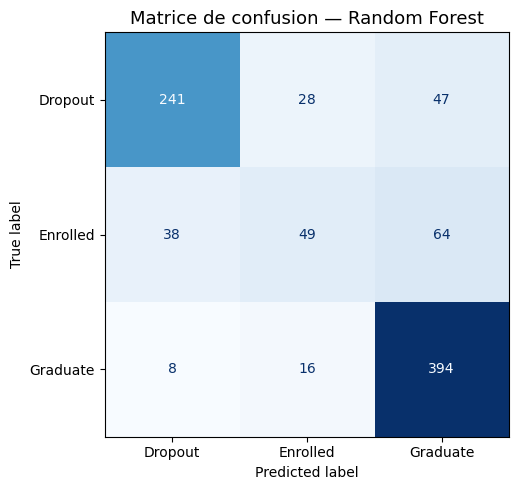

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Dropout", "Enrolled", "Graduate"]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matrice de confusion — Random Forest", fontsize=13)

plt.tight_layout()
plt.savefig("figures/04_matrice_confusion.png")
plt.show()

In [1]:
import subprocess
subprocess.run(["pip", "install", "shap"])
print("✅ SHAP installé !")

✅ SHAP installé !


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Charger les données
df = pd.read_csv("data/dataset.csv")

# Préparer les données
df_model = df.copy()
le = LabelEncoder()
df_model["Target"] = le.fit_transform(df_model["Target"])

# Séparer X et y
X = df_model.drop("Target", axis=1)
y = df_model["Target"]

# Découper en train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entraîner Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("✅ Tout est prêt ! Le modèle Random Forest est entraîné.")

✅ Tout est prêt ! Le modèle Random Forest est entraîné.


In [4]:
import shap

# Créer l'explainer SHAP pour notre Random Forest
explainer = shap.TreeExplainer(rf)

# Calculer les valeurs SHAP sur les données de test
shap_values = explainer.shap_values(X_test)

print("✅ Valeurs SHAP calculées !")
print(f"Nombre de catégories : {len(shap_values)}")
print(f"Nombre d'étudiants analysés : {shap_values[0].shape[0]}")

✅ Valeurs SHAP calculées !
Nombre de catégories : 885
Nombre d'étudiants analysés : 34


In [5]:
import shap

# Créer l'explainer SHAP
explainer = shap.TreeExplainer(rf)

# Calculer les valeurs SHAP
shap_values = explainer.shap_values(X_test)

# Vérifier la forme correctement
print("✅ Valeurs SHAP calculées !")
print(f"Type : {type(shap_values)}")
print(f"Forme : {np.array(shap_values).shape}")

✅ Valeurs SHAP calculées !
Type : <class 'numpy.ndarray'>
Forme : (885, 34, 3)


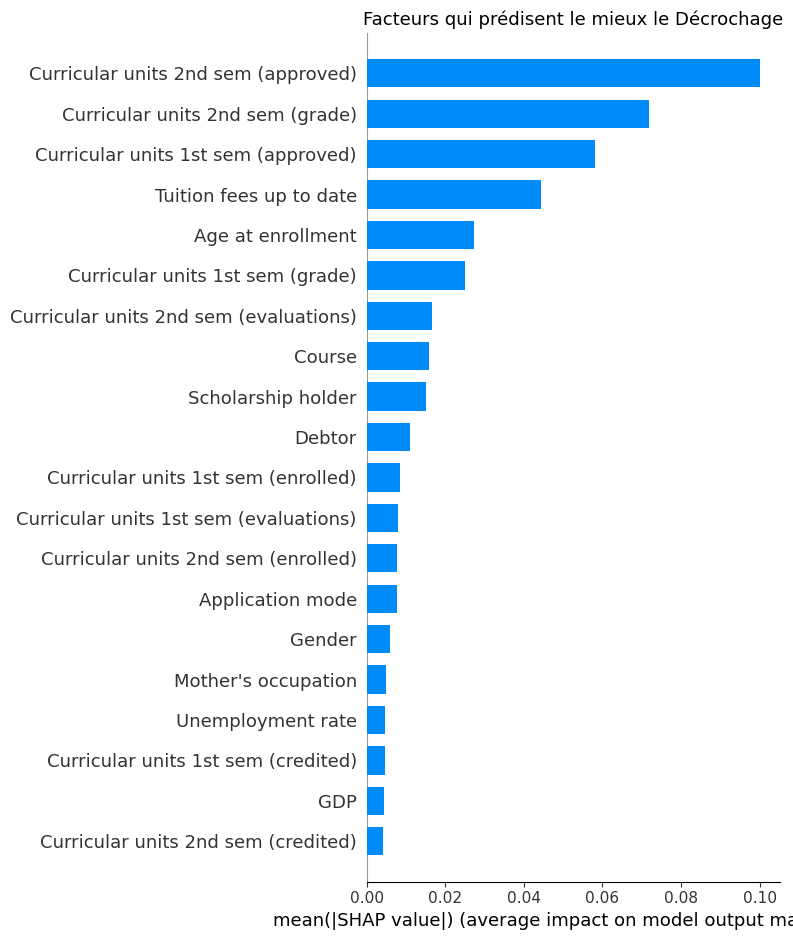

✅ Graphique sauvegardé !


In [6]:
# On se concentre sur les Dropout (catégorie 0)
# C'est la plus importante pour notre projet

shap.summary_plot(
    shap_values[:, :, 0],  # 0 = Dropout
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Facteurs qui prédisent le mieux le Décrochage", fontsize=13)
plt.tight_layout()
plt.savefig("figures/05_shap_importance.png", bbox_inches="tight")
plt.show()

print("✅ Graphique sauvegardé !")

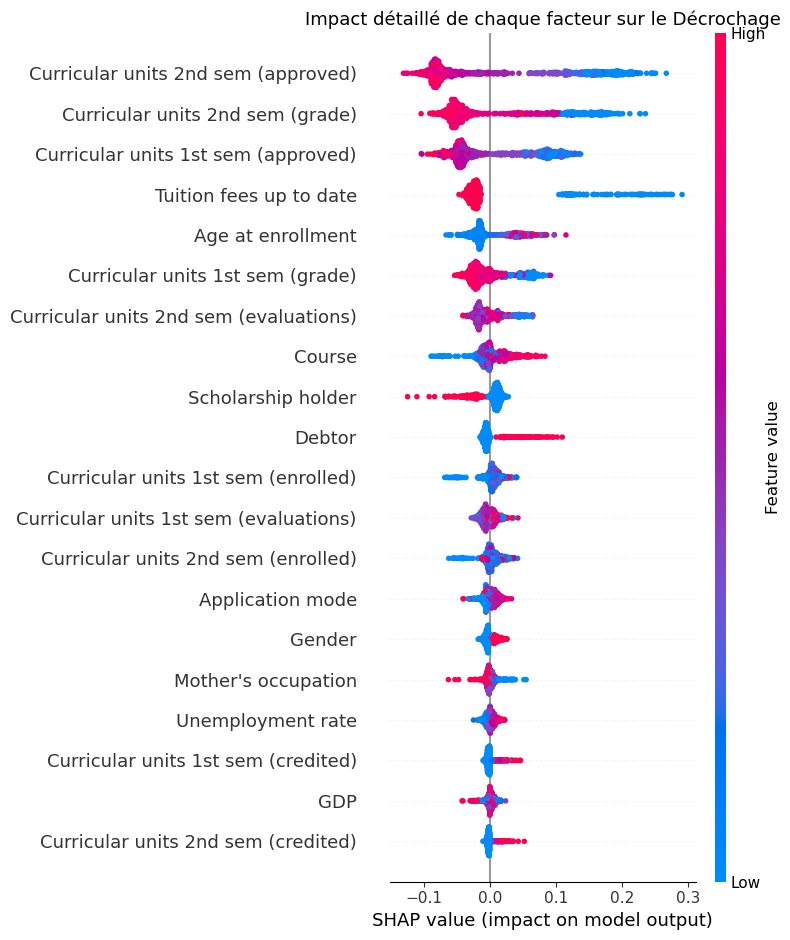

In [7]:
# Graphique SHAP avec les valeurs détaillées
plt.figure()
shap.summary_plot(
    shap_values[:, :, 0],
    X_test,
    show=False
)

plt.title("Impact détaillé de chaque facteur sur le Décrochage", fontsize=13)
plt.tight_layout()
plt.savefig("figures/06_shap_detail.png", bbox_inches="tight")
plt.show()